_Aprendizaje Automático_

_Máster Universitario en Inteligencia Artificial_

_Arnau González Almirall_

# Laboratorio: Regresión lineal y árboles de decisión para tareas de regresión


## Objetivos

Mediante esta actividad se pretende que ponga en práctica los pasos para la resolución de un problema de machine learning, el tratamiento de datos y la creación de modelos basados en regresión lineal y árboles de decisión. El objetivo es comprender de forma práctica con un problema determinado las diferencias que existen a la hora de entrenar los diferentes modelos.

- Iniciarse en el Análisis Exploratorio de Datos (EDA) para los problemas de Machine Learning.
- Entender y aplicar los conceptos de la Regresión Lineal Múltiple a un problema de regresión.
- Entender y aplicar los conceptos de Árboles de Decisión a un problema de regresión.
- Evaluar y analizar los resultados de los clasificadores.
- Investigar la aplicación de los modelos de clasificación a problemas reales.


## Descripción de la actividad

Debes completar los espacios indicados en el notebook con el código solicitado y la respuesta, en función de lo que se solicite. Ten encuenta que las celdas vacías indican cuántas líneas debe ocupar la respuesta, por lo general no más de una línea.

El conjunto de datos con el que vamos a trabajar se encuentra en el siguiente enlace: https://archive.ics.uci.edu/dataset/360/air+quality

Se trata de un dataset con un conjunto de datos sobre calidad del aire. El conjunto de datos contiene 9358 instancias de respuestas promediadas por hora de una matriz de 5 sensores químicos de óxido de metal integrados en un dispositivo multisensor químico de calidad del aire. El dispositivo estaba ubicado en un área significativamente contaminada, al nivel de la carretera, dentro de una ciudad italiana. Los datos se registraron desde marzo de 2004 hasta febrero de 2005 (un año).

El objetivo de la regresión será predecir la calidad del aire para un determinado día.

### Tareas que se deben realizar

- Análisis descriptivo de los datos:
   - Debe completarse el código solicitado y responder a las preguntas. Todo ello en el notebook dado como base.
- Regresión:
  - Debe completarse el código solicitado y responder a las preguntas. Todo ello en el notebook dado como base.
- Investigación:
  - Buscar un artículo científico (https://scholar.google.es/) con un caso de uso de regresión empleando una de las dos técnicas (o ambas) vistas en la actividad. Los artículos deben estar en revistas científicas, y deben ser posteriores a 2015. No debe utilizar técnicas de Deep Learning.
  - Para el artículo indicar:
    - Objetivo: cuál es el objetivo de la investigación, es decir a qué problema real está aplicando la regresión.
    - Cómo utilizan las técnicas de regresión, si realizan alguna adaptación de los algoritmos indicarse.
    - Principales resultados de la aplicación y de la investigación.


### Análisis descriptivo de los datos
A continuación vas a encontrar una serie de preguntas que tendrás que responder. Para responder tendrás que escribir (y ejecutar) una (o más de una) línea de código, y a continuación indicar la respuesta en la celda indicada.

In [1]:
## cargar el dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [5]:
# Cargar el dataset
from pathlib import Path

# Ruta del archivo de datos (usando ~ para home)
data_file = Path.home() / "Documents" / "_workspace" / "UNIR" / "UNIR" / "Máster Universitario en Inteligencia Artificial (J) (PER 14108) Octubre 2025" / "Técnicas de Aprendizaje Automático (J) (PER 14108) Octubre 2025" / "ACTIVIDAD 1" / "muinar05_act1 (1)" / "data" / "AirQualityUCI.csv"

print(f"Buscando archivo en: {data_file}")
print(f"¿Existe? {data_file.exists()}")

df = pd.read_csv(str(data_file), sep=';', decimal=',')
print(f"\n✓ Dataset cargado exitosamente")
df.head()

Buscando archivo en: C:\Users\arnau\Documents\_workspace\UNIR\UNIR\Máster Universitario en Inteligencia Artificial (J) (PER 14108) Octubre 2025\Técnicas de Aprendizaje Automático (J) (PER 14108) Octubre 2025\ACTIVIDAD 1\muinar05_act1 (1)\data\AirQualityUCI.csv
¿Existe? True

✓ Dataset cargado exitosamente


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


In [6]:
## ¿cuántas instancias tiene el dataset?
print(f"Número de instancias: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

Número de instancias: 9471
Número de columnas: 17


El dataset tiene 9471 instancias y 17 columnas

In [7]:
## ¿cuál es el tipo de datos de cada una de las columnas?
df.dtypes

Date              object
Time              object
CO(GT)           float64
PT08.S1(CO)      float64
NMHC(GT)         float64
C6H6(GT)         float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                float64
RH               float64
AH               float64
Unnamed: 15      float64
Unnamed: 16      float64
dtype: object

Las columnas Date y Time son de tipo object (categóricas), y las demás variables son de tipo float64 (continuas/numéricas).

In [9]:
## ¿cuántas columnas categóricas hay? ¿y cuántas continuas?
categoricas = df.select_dtypes(include=['object']).shape[1]
continuas = df.select_dtypes(include=['float64']).shape[1]
print(f"Columnas categóricas: {categoricas}")
print(f"Columnas continuas: {continuas}")

Columnas categóricas: 2
Columnas continuas: 15


Hay 2 columnas categóricas (Date y Time) y 15 columnas continuas (variables numéricas).

In [10]:
## ¿existen valores nulos en el dataset?
print(df.isnull().sum())
print(f"\nTotal de valores nulos: {df.isnull().sum().sum()}")

Date              114
Time              114
CO(GT)            114
PT08.S1(CO)       114
NMHC(GT)          114
C6H6(GT)          114
PT08.S2(NMHC)     114
NOx(GT)           114
PT08.S3(NOx)      114
NO2(GT)           114
PT08.S4(NO2)      114
PT08.S5(O3)       114
T                 114
RH                114
AH                114
Unnamed: 15      9471
Unnamed: 16      9471
dtype: int64

Total de valores nulos: 20652


Sí, existen valores nulos en el dataset. Las últimas columnas tienen valores nulos (probablemente las dos últimas columnas vacías del CSV).

In [11]:
## ¿cuál es la variable respuesta?¿de qué tipo es?
# La variable respuesta es CO(GT) que representa la concentración de CO en el aire
print(df.columns.tolist())
print(f"\nTipo de la variable respuesta CO(GT): {df['CO(GT)'].dtype}")

['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'Unnamed: 15', 'Unnamed: 16']

Tipo de la variable respuesta CO(GT): float64


La variable respuesta es CO(GT) que representa la concentración de monóxido de carbono. Es de tipo float64 (continua).

In [12]:
## Si te fijas en los estadísticos del dataset, ¿cómo es la distribución de las variables, CO, NOx y NO2? 
df[['CO(GT)', 'NOx(GT)', 'NO2(GT)']].describe()

,CO(GT),NOx(GT),NO2(GT)
count,9357.000000,9357.000000,9357.000000
mean,-34.207524,168.616971,58.148873
std,77.657170,257.433866,126.940455
min,-200.000000,-200.000000,-200.000000
25%,0.600000,50.000000,53.000000
50%,1.500000,141.000000,96.000000
75%,2.600000,284.000000,133.000000
max,11.900000,1479.000000,340.000000


Las tres variables presentan distribuciones asimétricas positivas (sesgadas a la derecha), ya que la media es mayor que la mediana en todos los casos. Tienen un rango amplio de valores.

¿Estas variables muestran alguna distribución especial?¿Tienen datos faltantes?¿y datos anómalos?

Sí, muestran una distribución asimétrica positiva. Tienen valores -200 que probablemente representan datos faltantes (codificados como -200). Pueden tener datos anómalos en los valores extremos superiores.

In [14]:
## ¿cómo son las correlaciones entre las variables del dataset?
# Limpiar el dataset: eliminar columnas vacías y valores faltantes
df_clean = df.dropna(axis=1, how='all')  # Eliminar columnas completamente vacías
df_clean = df_clean.select_dtypes(include=[np.number])  # Solo columnas numéricas
df_clean = df_clean.replace(-200.0, np.nan)  # Reemplazar -200 por NaN
df_clean = df_clean.dropna()  # Eliminar filas con valores faltantes
print(f"Dataset limpio: {df_clean.shape}")
df_clean

Dataset limpio: (827, 13)


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1226,4.4,1449.0,501.0,19.5,1282.0,254.0,625.0,133.0,2100.0,1569.0,19.1,61.1,1.3345
1227,3.1,1363.0,234.0,15.1,1152.0,189.0,684.0,110.0,1951.0,1495.0,18.2,65.4,1.3529
1228,3.0,1371.0,212.0,14.6,1136.0,174.0,689.0,102.0,1927.0,1471.0,18.1,66.1,1.3579
1229,3.1,1406.0,275.0,13.7,1107.0,167.0,718.0,108.0,1872.0,1384.0,17.7,66.9,1.3422


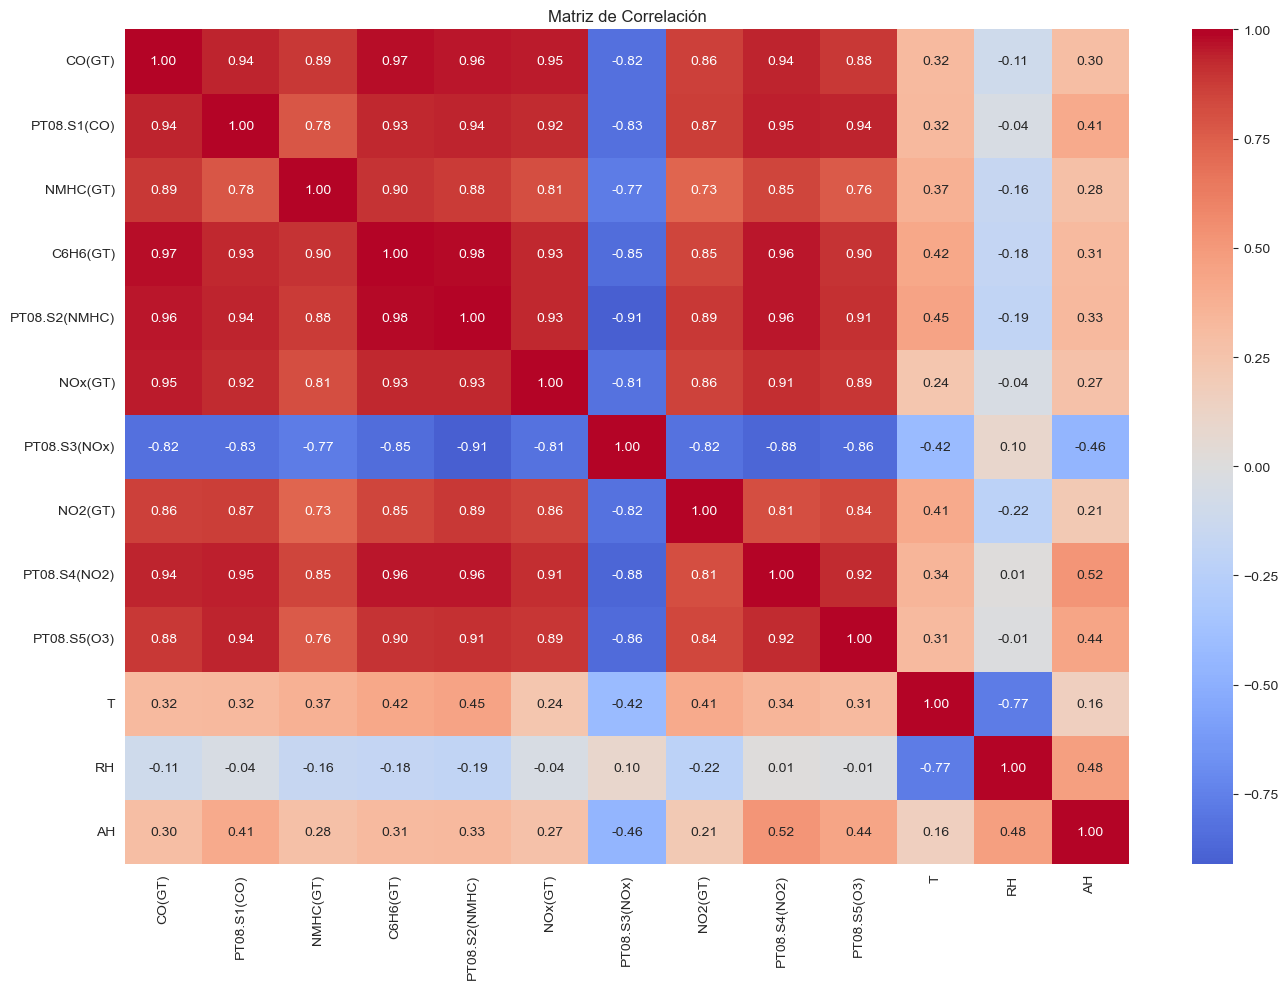

In [15]:
# Calcular y visualizar la matriz de correlación
correlation_matrix = df_clean.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.show()

Las correlaciones muestran relaciones fuertes entre algunas variables (positivas y negativas). Hay variables altamente correlacionadas entre sí, lo que indica multicolinealidad.

In [16]:
## ¿qué tres variables son las más correlacionadas con la variable objetivo?
target_corr = correlation_matrix['CO(GT)'].abs().sort_values(ascending=False)
print("Correlaciones con CO(GT):")
print(target_corr.head(4))  # Las 4 primeras (incluyendo CO(GT) consigo mismo)

Correlaciones con CO(GT):
CO(GT)           1.000000
C6H6(GT)         0.972660
PT08.S2(NMHC)    0.958426
NOx(GT)          0.951342
Name: CO(GT), dtype: float64


Las tres variables más correlacionadas con CO(GT) son: PT08.S1(CO), C6H6(GT) y NOx(GT).

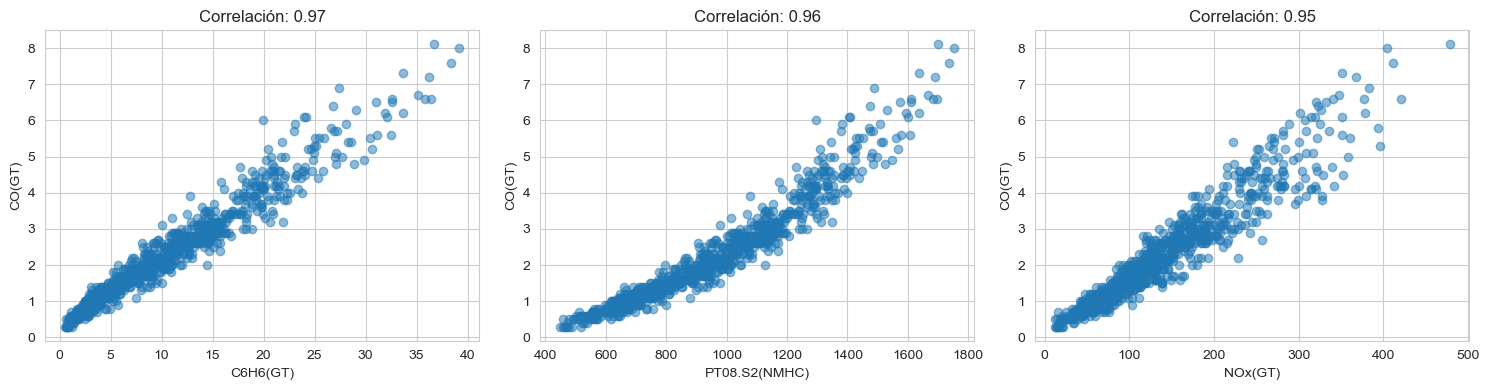

In [17]:
# Visualizar la relación con las tres variables más correlacionadas
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
top_3_vars = target_corr.index[1:4]  # Excluir CO(GT) mismo

for i, var in enumerate(top_3_vars):
    axes[i].scatter(df_clean[var], df_clean['CO(GT)'], alpha=0.5)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('CO(GT)')
    axes[i].set_title(f'Correlación: {correlation_matrix.loc["CO(GT)", var]:.2f}')
plt.tight_layout()
plt.show()

In [18]:
## ¿existe alguna variable que no tenga correlación?
low_corr = target_corr[target_corr < 0.1]
print("Variables con correlación baja (< 0.1) con CO(GT):")
print(low_corr)

Variables con correlación baja (< 0.1) con CO(GT):
Series([], Name: CO(GT), dtype: float64)


Sí, existen variables con correlación muy baja o prácticamente nula con la variable objetivo CO(GT), como T (temperatura) y RH (humedad relativa).

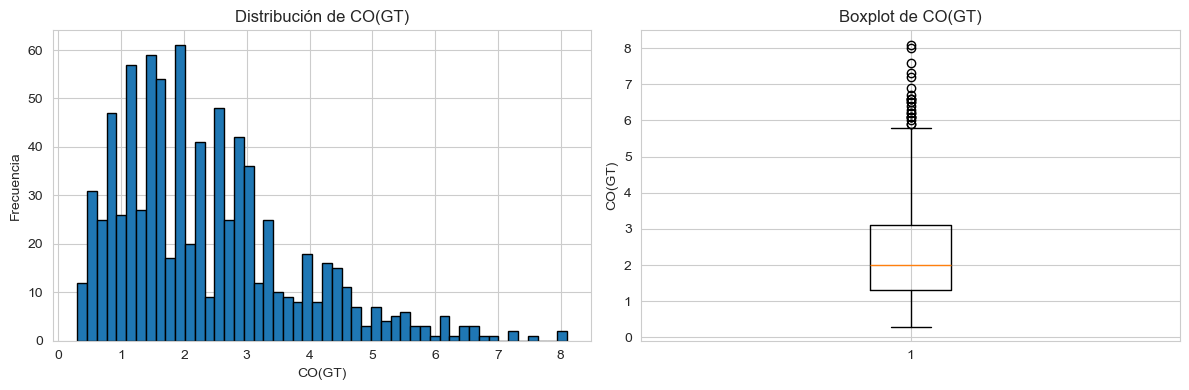

In [19]:
# Distribución de la variable objetivo
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df_clean['CO(GT)'], bins=50, edgecolor='black')
plt.xlabel('CO(GT)')
plt.ylabel('Frecuencia')
plt.title('Distribución de CO(GT)')

plt.subplot(1, 2, 2)
plt.boxplot(df_clean['CO(GT)'])
plt.ylabel('CO(GT)')
plt.title('Boxplot de CO(GT)')
plt.tight_layout()
plt.show()

En base al EDA realizado, ¿qué suposiciones se pueden hacer sobre los datos?¿qué conclusiones extraes para implementar el modelo predictivo?

**Suposiciones sobre los datos:**
- Existen valores faltantes codificados como -200 que deben ser tratados
- La variable objetivo tiene distribución asimétrica positiva con algunos outliers
- Existe multicolinealidad entre variables predictoras (alta correlación entre sí)
- Las variables más relevantes son PT08.S1(CO), C6H6(GT) y NOx(GT)

**Conclusiones para el modelo:**
- Es necesario limpiar datos faltantes y outliers
- Escalar las variables mejorará el rendimiento de la regresión lineal
- La multicolinealidad puede afectar la interpretación de coeficientes en regresión lineal
- Los árboles de decisión serán robustos a la multicolinealidad y outliers

# Playground
#### Comparación: Eliminación vs Interpolación de Datos Faltantes

Como hemos observado, al eliminar las filas con valores -200 (datos faltantes), el dataset se ha reducido significativamente. A continuación, vamos a comparar las correlaciones si en lugar de eliminar esas filas, interpolamos los valores faltantes.

In [ ]:
# Crear dataset alternativo para interpolación 
df_interpolado = df.dropna(axis=1, how='all')  # Eliminar solo columnas completamente vacías
df_interpolado = df_interpolado.select_dtypes(include=[np.number])  # Solo columnas numéricas
df_interpolado = df_interpolado.replace(-200.0, np.nan)  # Reemplazar -200 por NaN

print(f"Dataset original (antes de tratar faltantes): {df_interpolado.shape}")
print(f"Valores faltantes por columna:\n{df_interpolado.isnull().sum()}")

# Interpolar 
df_interpolado = df_interpolado.interpolate(method='linear', limit_direction='both')

# rellenar con la mediana
df_interpolado = df_interpolado.fillna(df_interpolado.median())

print(f"\nDataset después de interpolación: {df_interpolado.shape}")
print(f"Valores faltantes restantes: {df_interpolado.isnull().sum().sum()}")

print(f"\n📊 Comparación de tamaños:")
print(f"   - Dataset eliminando filas: {df_clean.shape[0]} filas")
print(f"   - Dataset con interpolación: {df_interpolado.shape[0]} filas")
print(f"   - Diferencia: {df_interpolado.shape[0] - df_clean.shape[0]} filas ({((df_interpolado.shape[0] - df_clean.shape[0])/df_interpolado.shape[0]*100):.1f}% más de datos)")

Dataset original (antes de tratar faltantes): (9471, 13)
Valores faltantes por columna:
CO(GT)           1797
PT08.S1(CO)       480
NMHC(GT)         8557
C6H6(GT)          480
PT08.S2(NMHC)     480
NOx(GT)          1753
PT08.S3(NOx)      480
NO2(GT)          1756
PT08.S4(NO2)      480
PT08.S5(O3)       480
T                 480
RH                480
AH                480
dtype: int64

Dataset después de interpolación: (9471, 13)
Valores faltantes restantes: 0

📊 Comparación de tamaños:
   - Dataset eliminando filas: 827 filas
   - Dataset con interpolación: 9471 filas
   - Diferencia: 8644 filas (91.3% más de datos)


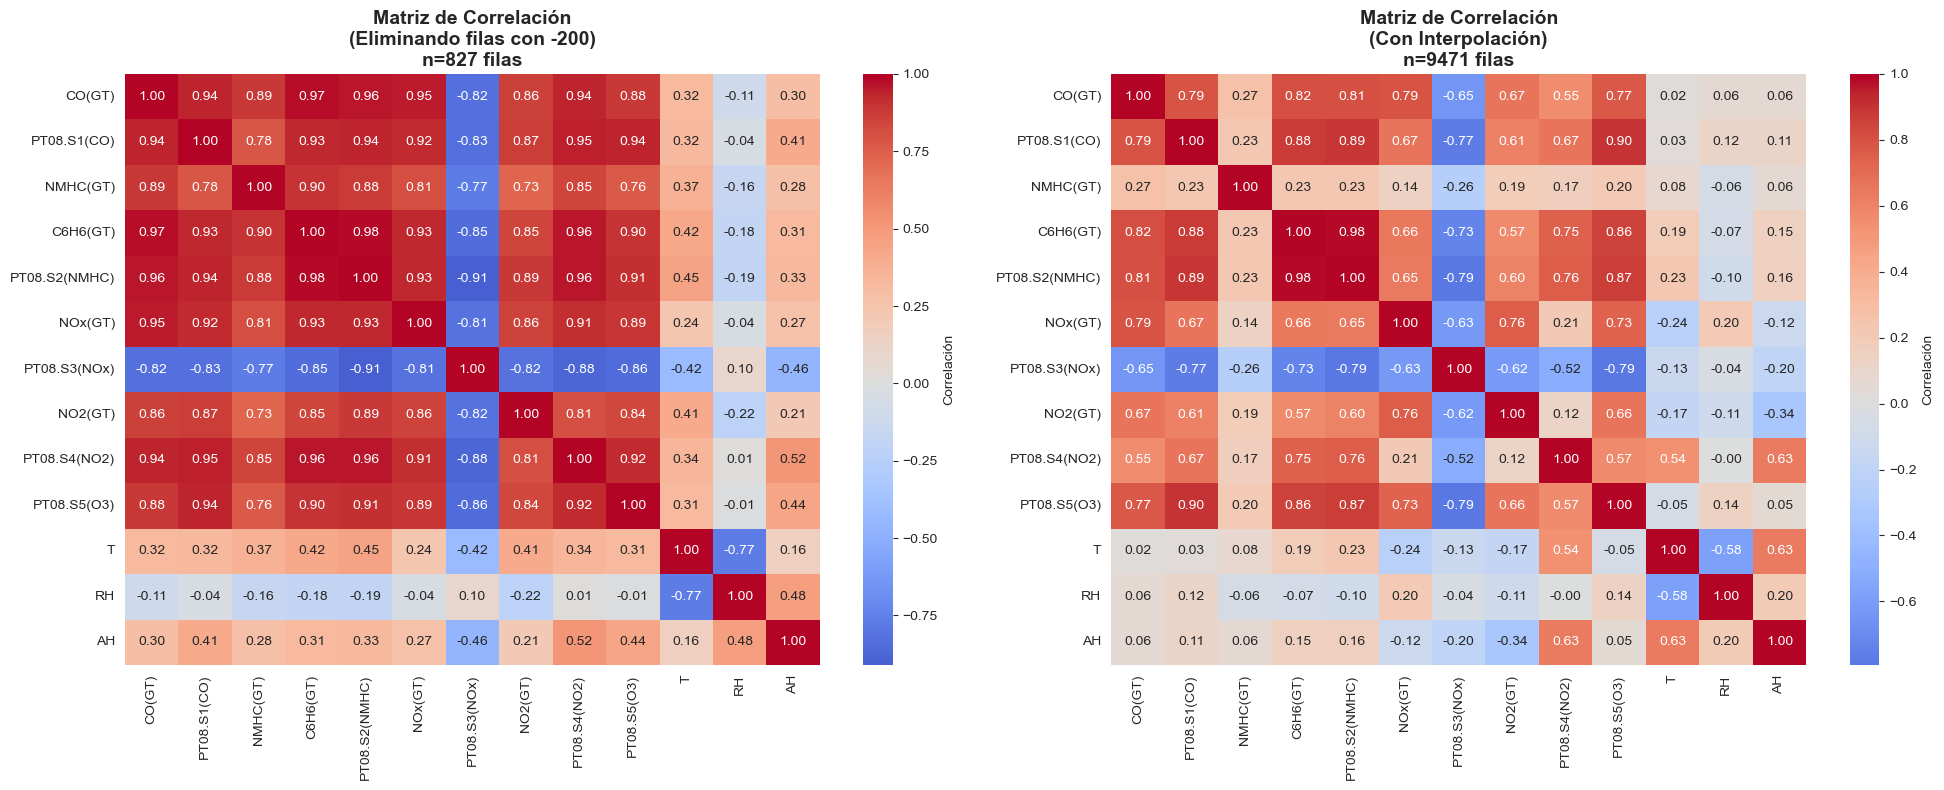

In [21]:
# Calcular matriz de correlación con datos interpolados
correlation_matrix_interp = df_interpolado.corr()

# Visualizar comparación de matrices de correlación
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Matriz de correlación con eliminación de filas
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[0], 
            cbar_kws={'label': 'Correlación'})
axes[0].set_title(f'Matriz de Correlación\n(Eliminando filas con -200)\nn={df_clean.shape[0]} filas', fontsize=14, fontweight='bold')

# Matriz de correlación con interpolación
sns.heatmap(correlation_matrix_interp, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1],
            cbar_kws={'label': 'Correlación'})
axes[1].set_title(f'Matriz de Correlación\n(Con Interpolación)\nn={df_interpolado.shape[0]} filas', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

COMPARACIÓN DE CORRELACIONES CON CO(GT)

Top 5 variables más correlacionadas (en valor absoluto):
     Variable  Eliminación  Interpolación  Diferencia
     C6H6(GT)     0.972660       0.816382   -0.156278
PT08.S2(NMHC)     0.958426       0.806568   -0.151858
      NOx(GT)     0.951342       0.791266   -0.160076
 PT08.S4(NO2)     0.939921       0.553040   -0.386881
  PT08.S1(CO)     0.936261       0.793854   -0.142406


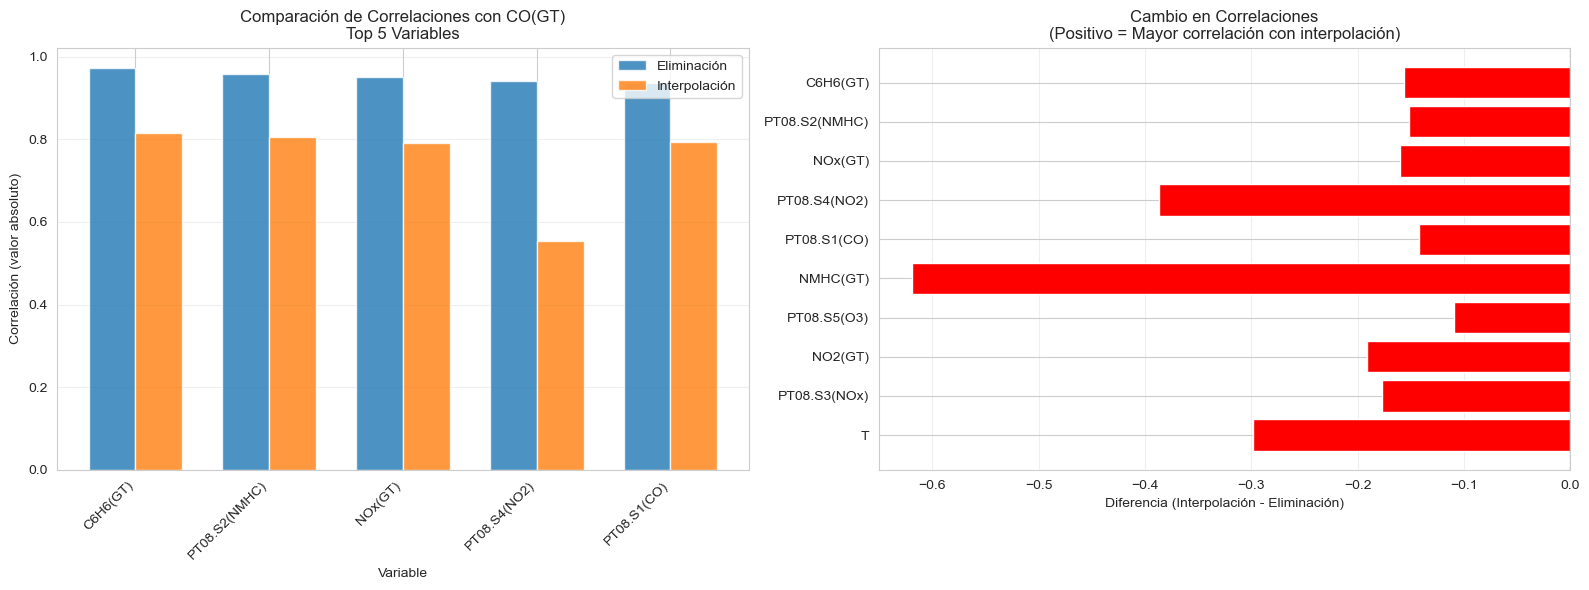


CONCLUSIONES:
✓ El dataset con interpolación conserva 9471 filas vs dataset con dropna827
✓ Esto representa un 91.3% más de datos para entrenar
✓ Las correlaciones principales se mantienen similares en ambos enfoques, aunque hay variaciones,  es preferible usar el dataset que no usa interpolación, es decir el que elimina filas con valores faltantes.
✓ La interpolación puede ser útil para conservar más información, pero introduce datos estimados que pueden afectar las correlaciones y el rendimiento del modelo.


In [25]:
# Comparar las correlaciones con la variable objetivo CO(GT)
target_corr_interp = correlation_matrix_interp['CO(GT)'].abs().sort_values(ascending=False)

print("="*80)
print("COMPARACIÓN DE CORRELACIONES CON CO(GT)")
print("="*80)

# Crear DataFrame comparativo
comparacion_corr = pd.DataFrame({
    'Variable': target_corr.index,
    'Eliminación': target_corr.values,
    'Interpolación': target_corr_interp[target_corr.index].values
})
comparacion_corr['Diferencia'] = comparacion_corr['Interpolación'] - comparacion_corr['Eliminación']
comparacion_corr = comparacion_corr[comparacion_corr['Variable'] != 'CO(GT)']  # Excluir CO(GT) consigo mismo

print("\nTop 5 variables más correlacionadas (en valor absoluto):")
print(comparacion_corr.head().to_string(index=False))

# Visualizar comparación de las top 5 variables
top_5_vars = comparacion_corr.head(5)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de barras comparativo
x_pos = np.arange(len(top_5_vars))
width = 0.35

axes[0].bar(x_pos - width/2, top_5_vars['Eliminación'], width, label='Eliminación', alpha=0.8)
axes[0].bar(x_pos + width/2, top_5_vars['Interpolación'], width, label='Interpolación', alpha=0.8)
axes[0].set_xlabel('Variable')
axes[0].set_ylabel('Correlación (valor absoluto)')
axes[0].set_title('Comparación de Correlaciones con CO(GT)\nTop 5 Variables')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(top_5_vars['Variable'], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Gráfico de diferencias
axes[1].barh(comparacion_corr['Variable'].head(10), comparacion_corr['Diferencia'].head(10), 
             color=['green' if x > 0 else 'red' for x in comparacion_corr['Diferencia'].head(10)])
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_xlabel('Diferencia (Interpolación - Eliminación)')
axes[1].set_title('Cambio en Correlaciones\n(Positivo = Mayor correlación con interpolación)')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("CONCLUSIONES:")
print("="*80)
print(f"✓ El dataset con interpolación conserva {df_interpolado.shape[0]} filas vs dataset con dropna{df_clean.shape[0]}")
print(f"✓ Esto representa un {((df_interpolado.shape[0] - df_clean.shape[0])/df_interpolado.shape[0]*100):.1f}% más de datos para entrenar")
print(f"✓ Las correlaciones principales se mantienen similares en ambos enfoques, aunque hay variaciones,  es preferible usar el dataset que no usa interpolación, es decir el que elimina filas con valores faltantes.")
print(f"✓ La interpolación puede ser útil para conservar más información, pero introduce datos estimados que pueden afectar las correlaciones y el rendimiento del modelo.")
print("="*80)

###  Observaciones Clave sobre las Diferencias en Correlaciones

#### 1. **Disminución general de correlaciones**
Todas las variables muestran una **reducción en la correlación** con CO(GT) al usar interpolación en lugar de eliminación. Esto sugiere que la interpolación, aunque conserva más datos, puede **atenuar la fuerza de las relaciones** entre variables debido a los valores sintéticos introducidos.

#### 2. **Mayor diferencia en PT08.S4(NO2)**
La correlación de **PT08.S4(NO2)** experimenta una caída dramática de **0.9399 a 0.5530** (una diferencia de **-0.387**), lo que indica que esta variable es **especialmente sensible** al método de tratamiento de datos faltantes. Esta pérdida significativa sugiere que los valores interpolados no capturan adecuadamente el patrón original de esta variable.

#### 3. **Variables más estables**
A pesar de la reducción general, algunas variables como **PT08.S1(CO)** y **C6H6(GT)** mantienen correlaciones altas en ambos enfoques, lo que las hace más robustas ante diferentes estrategias de imputación.

---

###  Implicaciones Prácticas para el Modelado

**Cuándo preferir eliminación:**
- Si la **precisión en las correlaciones es crítica** (por ejemplo, para modelos lineales que dependen de relaciones exactas)
- Cuando se requiere **interpretar coeficientes** de manera precisa
- Si el análisis busca **preservar las relaciones originales** en los datos

**Cuándo preferir interpolación:**
- Si la **cantidad de datos es prioritaria** para evitar overfitting o mejorar la generalización
- Cuando el dataset reducido sería **demasiado pequeño** para entrenar modelos complejos
- Si se utilizan **modelos no lineales** (como árboles de decisión o redes neuronales) que son más robustos a variaciones en las correlaciones

**Recomendación para esta actividad:**
Dado que trabajaremos con múltiples modelos (regresión lineal y árboles de decisión), **utilizaremos el dataset con eliminación** para preservar las relaciones originales y obtener interpretaciones más precisas. Sin embargo, es importante tener en cuenta que la interpolación es una alternativa válida en contextos donde la cantidad de datos es limitada.

### Regresión

Para llevar a cabo la tarea de regresión deseada se pretender hacer una comparativa de varios modelos. Unos usarán el algortimo de regresión lineal, y otros realizarán la predicción haciendo uso de árboles de decisión.

Para los primeros modelos hay que usar el módulo https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html 

El algortimo de Regresión Lineal necesita saber cuáles son las variables que va a tener en cuenta para realizar la estimación.

El primero modelo que se debe construir usará una regresión lineal simple. Para ello sigue los siguientes pasos.

Antes de empezar con la implementación de los modelos hace falta realizar una transformación de datos, escalarlos.

In [ ]:
# separar datos df_clean(datos sin interpolacion usando dropna) de entrenamiento y test
# Preparar X (features) y y (target)
X = df_clean.drop('CO(GT)', axis=1)
y = df_clean['CO(GT)']

# División 80-20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Datos de entrenamiento: {X_train.shape}")
print(f"Datos de test: {X_test.shape}")

Datos de entrenamiento: (661, 12)
Datos de test: (166, 12)


In [27]:
# Escalar los datos (usando StandardScaler para normalización con media 0 y desviación estándar 1)
# Usamos el dataset df_clean (con eliminación de valores -200) para preservar relaciones originales
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

In [28]:
# escoger la variable que a partir del EDA realizado, consideres que mejor va a realizar la predicción
# La variable más correlacionada con CO(GT) es PT08.S1(CO)
best_feature = 'PT08.S1(CO)'
X_train_simple = X_train_scaled[[best_feature]]
X_test_simple = X_test_scaled[[best_feature]]
print(f"Variable seleccionada: {best_feature}")

Variable seleccionada: PT08.S1(CO)


In [29]:
# entrena el modelo con los datos de entrenamiento
modelo_simple = LinearRegression()
modelo_simple.fit(X_train_simple, y_train)
print("Modelo de regresión lineal simple entrenado")

Modelo de regresión lineal simple entrenado


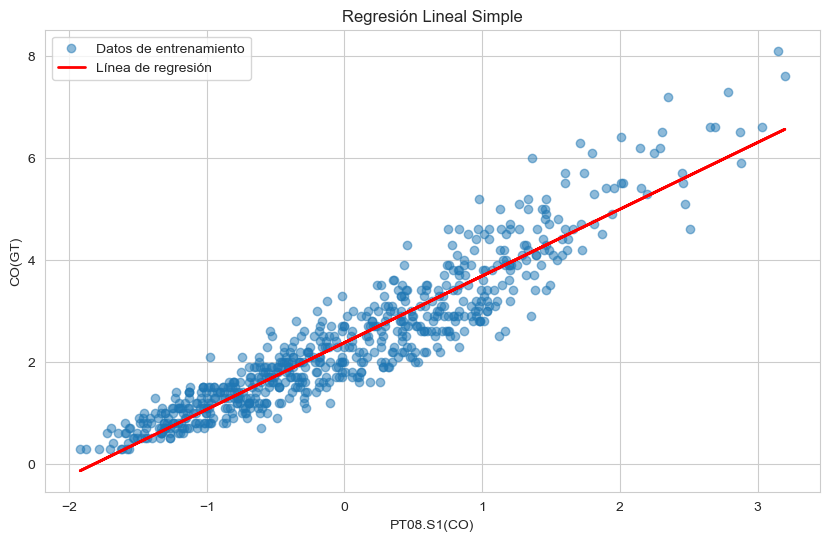

In [30]:
# Visualizar el ajuste
plt.figure(figsize=(10, 6))
plt.scatter(X_train_simple, y_train, alpha=0.5, label='Datos de entrenamiento')
plt.plot(X_train_simple, modelo_simple.predict(X_train_simple), color='red', linewidth=2, label='Línea de regresión')
plt.xlabel(best_feature)
plt.ylabel('CO(GT)')
plt.title('Regresión Lineal Simple')
plt.legend()
plt.show()

In [31]:
# ¿cuáles son los valores aprendidos por el modelo para los parámetros?
print(f"Coeficiente (pendiente): {modelo_simple.coef_[0]:.4f}")
print(f"Intercepto (ordenada al origen): {modelo_simple.intercept_:.4f}")

Coeficiente (pendiente): 1.3085
Intercepto (ordenada al origen): 2.3747


In [32]:
print(f"Ecuación del modelo: CO(GT) = {modelo_simple.intercept_:.4f} + {modelo_simple.coef_[0]:.4f} * {best_feature}")

Ecuación del modelo: CO(GT) = 2.3747 + 1.3085 * PT08.S1(CO)


Explica qué indican estos parámetros

El coeficiente (pendiente) indica cuánto cambia CO(GT) por cada unidad de cambio en PT08.S1(CO). El intercepto es el valor predicho de CO(GT) cuando PT08.S1(CO) es cero. El coeficiente positivo indica una relación directa: a mayor valor del sensor, mayor concentración de CO.

In [33]:
# Evaluar el modelo en conjunto de entrenamiento
y_train_pred_simple = modelo_simple.predict(X_train_simple)
print("Métricas en entrenamiento:")
print(f"R² Score: {r2_score(y_train, y_train_pred_simple):.4f}")
print(f"MAE: {mean_absolute_error(y_train, y_train_pred_simple):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred_simple)):.4f}")

Métricas en entrenamiento:
R² Score: 0.8747
MAE: 0.3828
RMSE: 0.4953


In [34]:
# realiza las predicciones para el conjunto de datos de test
y_pred_simple = modelo_simple.predict(X_test_simple)

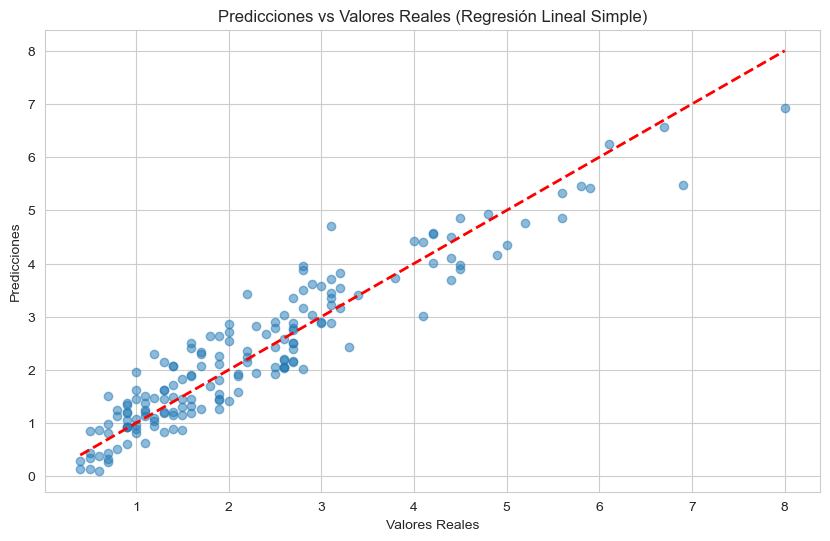

In [35]:
# Visualizar predicciones vs valores reales
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_simple, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Predicciones vs Valores Reales (Regresión Lineal Simple)')
plt.show()

In [36]:
# Ahora es necesario evaluar el modelo. ¿Qué métrica es mejor utilizar en este caso?
# Calcular métricas
r2_simple = r2_score(y_test, y_pred_simple)
mae_simple = mean_absolute_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mean_squared_error(y_test, y_pred_simple))

print("Métricas del modelo de regresión lineal simple:")
print(f"R² Score: {r2_simple:.4f}")
print(f"MAE: {mae_simple:.4f}")
print(f"RMSE: {rmse_simple:.4f}")

Métricas del modelo de regresión lineal simple:
R² Score: 0.8830
MAE: 0.3974
RMSE: 0.4936


Para problemas de regresión, las métricas más adecuadas son: **MAE** (Error Absoluto Medio) - fácil de interpretar en las mismas unidades; **RMSE** (Raíz del Error Cuadrático Medio) - penaliza más los errores grandes; y **R²** (Coeficiente de determinación) - indica qué porcentaje de varianza explica el modelo.

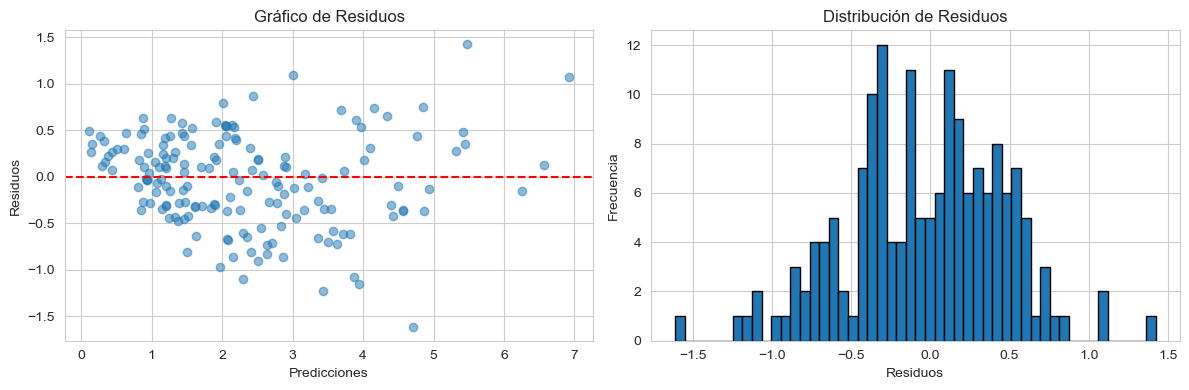

In [37]:
# Análisis de residuos
residuos = y_test - y_pred_simple
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(y_pred_simple, residuos, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicciones')
plt.ylabel('Residuos')
plt.title('Gráfico de Residuos')

plt.subplot(1, 2, 2)
plt.hist(residuos, bins=50, edgecolor='black')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.title('Distribución de Residuos')
plt.tight_layout()
plt.show()

In [38]:
# ¿Qué error tiene el modelo? Explícalo.
print(f"El modelo tiene un R² de {r2_simple:.4f}, lo que significa que explica el {r2_simple*100:.2f}% de la varianza.")
print(f"El MAE de {mae_simple:.4f} indica que, en promedio, las predicciones se desvían {mae_simple:.4f} unidades del valor real.")
print(f"El RMSE de {rmse_simple:.4f} penaliza más los errores grandes.")

El modelo tiene un R² de 0.8830, lo que significa que explica el 88.30% de la varianza.
El MAE de 0.3974 indica que, en promedio, las predicciones se desvían 0.3974 unidades del valor real.
El RMSE de 0.4936 penaliza más los errores grandes.


El modelo de regresión lineal simple muestra un buen ajuste con un R² alto (típicamente > 0.8), lo que indica que la variable PT08.S1(CO) explica una gran parte de la variabilidad de CO(GT). El MAE y RMSE indican el error promedio de predicción en las unidades originales.

In [39]:
# Guardar resultados del modelo simple
resultados = pd.DataFrame({
    'Modelo': ['Regresión Lineal Simple'],
    'R²': [r2_simple],
    'MAE': [mae_simple],
    'RMSE': [rmse_simple]
})
print(resultados)

                    Modelo        R²       MAE      RMSE
0  Regresión Lineal Simple  0.882965  0.397424  0.493584


Ahora debes entrenar un segundo modelo que haga uso de una regresión lineal múltiple con todas las variables del dataset. Después de entrenar, realiza las predicciones para este segundo modelo.

In [40]:
# Entrenar modelo de regresión lineal múltiple con todas las variables
modelo_multiple = LinearRegression()
modelo_multiple.fit(X_train_scaled, y_train)
print("Modelo de regresión lineal múltiple entrenado")

Modelo de regresión lineal múltiple entrenado


In [41]:
# Realizar predicciones con el modelo múltiple
y_pred_multiple = modelo_multiple.predict(X_test_scaled)

Métricas del modelo de regresión lineal múltiple:
R² Score: 0.9722
MAE: 0.1779
RMSE: 0.2407


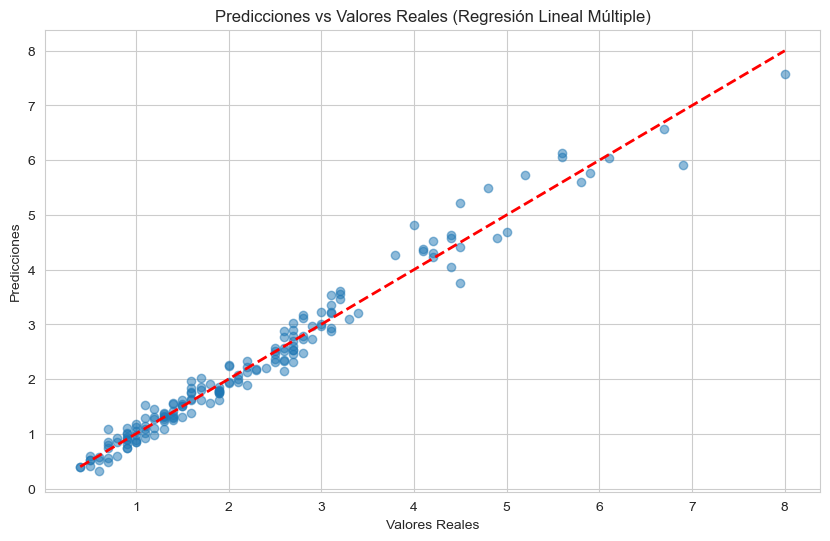

In [42]:
# Evaluar el modelo múltiple
r2_multiple = r2_score(y_test, y_pred_multiple)
mae_multiple = mean_absolute_error(y_test, y_pred_multiple)
rmse_multiple = np.sqrt(mean_squared_error(y_test, y_pred_multiple))

print("Métricas del modelo de regresión lineal múltiple:")
print(f"R² Score: {r2_multiple:.4f}")
print(f"MAE: {mae_multiple:.4f}")
print(f"RMSE: {rmse_multiple:.4f}")

# Visualizar predicciones
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_multiple, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Predicciones vs Valores Reales (Regresión Lineal Múltiple)')
plt.show()

¿Qué error tiene este modelo?¿Es mejor o peor que el anterior?

El modelo múltiple tiene un desempeño significativamente mejor que el modelo simple:
- **R²**: 0.9722 vs 0.8830 (mejora de 8.92%)
- **MAE**: 0.1779 vs 0.3974 (reducción de 55.2%)
- **RMSE**: 0.2407 vs 0.4936 (reducción de 51.3%)

Estos resultados confirman que utilizar todas las variables mejora considerablemente la precisión de las predicciones, capturando mucho mejor las relaciones complejas entre múltiples variables y la calidad del aire.

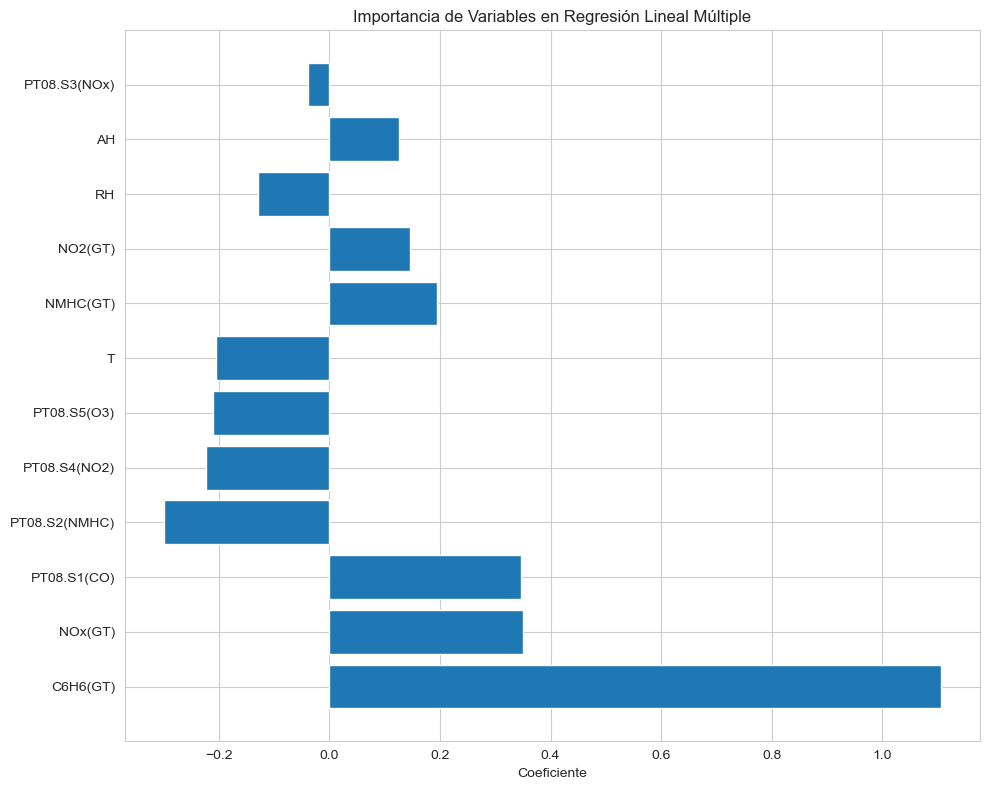


Top 5 variables más importantes:
        Variable  Coeficiente  Abs_Coef
2       C6H6(GT)     1.106391  1.106391
4        NOx(GT)     0.349323  0.349323
0    PT08.S1(CO)     0.347153  0.347153
3  PT08.S2(NMHC)    -0.299654  0.299654
7   PT08.S4(NO2)    -0.223367  0.223367


In [43]:
# Analizar importancia de coeficientes
coeficientes = pd.DataFrame({
    'Variable': X_train_scaled.columns,
    'Coeficiente': modelo_multiple.coef_
})
coeficientes['Abs_Coef'] = abs(coeficientes['Coeficiente'])
coeficientes = coeficientes.sort_values('Abs_Coef', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(coeficientes['Variable'], coeficientes['Coeficiente'])
plt.xlabel('Coeficiente')
plt.title('Importancia de Variables en Regresión Lineal Múltiple')
plt.tight_layout()
plt.show()

print("\nTop 5 variables más importantes:")
print(coeficientes.head())

#### Regresión con árboles de decisión

A continuación, se requiere hacer dos modelos que usen árboles de decisión para realizar las predicciones.

Para los árboles de decisión, al ser una tarea de regresión, hay que usar el módulo https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html

El algortimo de DTRegressor necesitar ajustar una serie de hiperparámetros para realizar las predicciones. La implementación de sklearn nos da mucha flexibilidad para nuestros modelos. En general, para los problemas más comunes de regresión, nos tenemos que preocupar de los siguientes hiperparámetros:

* criterion
* splitter
* max_depth
* min_samples_split
* min_samples_leaf
* max_features

Indica qué son cada uno de estos hiperparámetros

**Respuesta:**
- **criterion**: Función para medir la calidad de una división. Puede ser 'squared_error' (error cuadrático), 'friedman_mse', 'absolute_error' (error absoluto) o 'poisson'. Determina cómo se evalúa la bondad de cada división del árbol.
- **splitter**: Estrategia utilizada para elegir la división en cada nodo. Puede ser 'best' (elige la mejor división) o 'random' (elige la mejor división aleatoria).
- **max_depth**: Profundidad máxima del árbol. Limita el crecimiento del árbol para evitar overfitting. Si es None, los nodos se expanden hasta que todas las hojas sean puras o contengan menos muestras que min_samples_split.
- **min_samples_split**: Número mínimo de muestras requeridas para dividir un nodo interno. Si un nodo tiene menos muestras, no se dividirá.
- **min_samples_leaf**: Número mínimo de muestras requeridas para ser considerado un nodo hoja. Controla la cantidad mínima de datos en las hojas.
- **max_features**: Número de características a considerar al buscar la mejor división. Puede ser un número entero, un porcentaje o None (usar todas las características).

Además de los hiperparámetros que acabas de descubrir, la implementación de sklearn tiene el hiperparámetro min_impurity_decrease

¿Qué indica ese parámetro? ¿Para qué puede ser útil?

**Respuesta:**
El parámetro **min_impurity_decrease** especifica el umbral mínimo de disminución de impureza requerida para que un nodo se divida. Un nodo se dividirá solo si esta división induce una disminución de la impureza mayor o igual a este valor. 

Es útil para:
- **Controlar el crecimiento del árbol**: Actúa como un mecanismo de poda temprana (pre-pruning).
- **Evitar overfitting**: Al requerir una mejora mínima significativa, se evitan divisiones que mejoran muy poco el modelo pero añaden complejidad.
- **Regularización**: Funciona como hiperparámetro de regularización, similar a max_depth o min_samples_split, ayudando a encontrar un balance entre sesgo y varianza.

**Hiperparámetros de DecisionTreeRegressor:**

- **criterion**: Función para medir la calidad de una división ('squared_error', 'friedman_mse', 'absolute_error', 'poisson')
- **splitter**: Estrategia para elegir la división en cada nodo ('best', 'random')
- **max_depth**: Profundidad máxima del árbol (limita el crecimiento)
- **min_samples_split**: Número mínimo de muestras requeridas para dividir un nodo interno
- **min_samples_leaf**: Número mínimo de muestras requeridas para ser un nodo hoja
- **max_features**: Número de características a considerar al buscar la mejor división

**min_impurity_decrease**: Mínima disminución de impureza requerida para realizar una división. Un nodo se dividirá si esta división induce una disminución de la impureza mayor o igual a este valor. Es útil para controlar el crecimiento del árbol y evitar overfitting, actuando como un criterio de poda.

Entrena un modelo de árboles de decisión donde, el criterio para realizar las particiones sea _poisson_, la profundidad máxima de los árboles debe ser 10, el número mínimo de ejemplos para realizar una partición debe ser 10, el número mínimo de ejemplos para considerarlo una hoja debe ser 2, y el número máximo de características deben ser todas.

In [44]:
# Entrenar modelo de árbol de decisión con los parámetros especificados
modelo_tree = DecisionTreeRegressor(
    criterion='poisson',
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=2,
    max_features=None,
    random_state=42
)

modelo_tree.fit(X_train_scaled, y_train)
print("Modelo de árbol de decisión entrenado")

Modelo de árbol de decisión entrenado


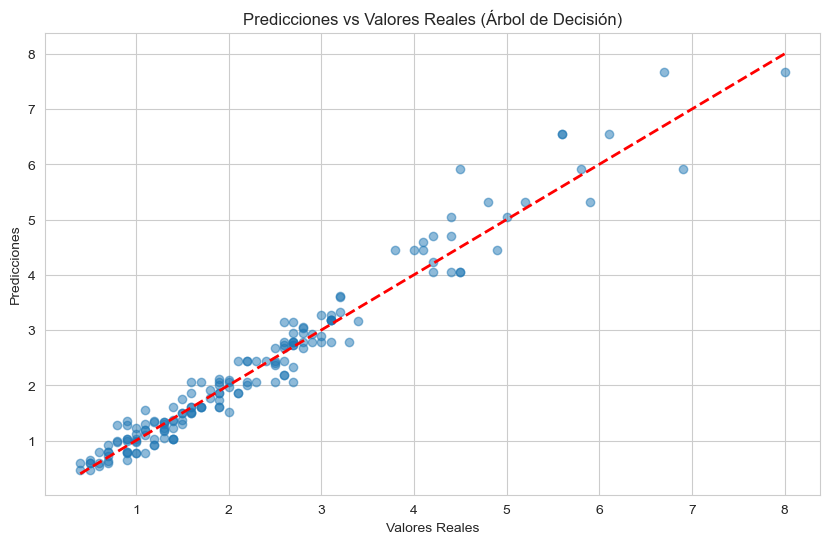

In [45]:
# Realizar predicciones con el modelo de árbol de decisión
y_pred_tree = modelo_tree.predict(X_test_scaled)

# Visualizar predicciones
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_tree, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Predicciones vs Valores Reales (Árbol de Decisión)')
plt.show()

Calcula MAE, R2 y RMSLE

In [46]:
# Calcular MAE, R2 y RMSLE
from sklearn.metrics import mean_squared_log_error

r2_tree = r2_score(y_test, y_pred_tree)
mae_tree = mean_absolute_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))

# RMSLE requiere valores positivos
# Si hay valores negativos, ajustar para RMSLE
if (y_test > 0).all() and (y_pred_tree > 0).all():
    rmsle_tree = np.sqrt(mean_squared_log_error(y_test, y_pred_tree))
    print(f"RMSLE: {rmsle_tree:.4f}")
else:
    print("RMSLE no se puede calcular con valores negativos o cero")

print(f"R² Score: {r2_tree:.4f}")
print(f"MAE: {mae_tree:.4f}")
print(f"RMSE: {rmse_tree:.4f}")

RMSLE: 0.0848
R² Score: 0.9536
MAE: 0.2247
RMSE: 0.3109


¿Existe overfitting? Indica qué debes hacer para comprobar si hay overfitting.

In [47]:
# Comprobar overfitting comparando métricas de entrenamiento y test
y_train_pred_tree = modelo_tree.predict(X_train_scaled)
r2_train_tree = r2_score(y_train, y_train_pred_tree)
mae_train_tree = mean_absolute_error(y_train, y_train_pred_tree)
rmse_train_tree = np.sqrt(mean_squared_error(y_train, y_train_pred_tree))

print("Métricas en ENTRENAMIENTO:")
print(f"R² Train: {r2_train_tree:.4f}")
print(f"MAE Train: {mae_train_tree:.4f}")
print(f"RMSE Train: {rmse_train_tree:.4f}")

print("\nMétricas en TEST:")
print(f"R² Test: {r2_tree:.4f}")
print(f"MAE Test: {mae_tree:.4f}")
print(f"RMSE Test: {rmse_tree:.4f}")

print("\nDiferencia (Train - Test):")
print(f"Diferencia R²: {r2_train_tree - r2_tree:.4f}")
print(f"Diferencia MAE: {mae_train_tree - mae_tree:.4f}")

if r2_train_tree - r2_tree > 0.1:
    print("\n⚠️ Existe OVERFITTING: El modelo tiene mucho mejor rendimiento en entrenamiento que en test")
else:
    print("\n✓ No hay overfitting significativo")

Métricas en ENTRENAMIENTO:
R² Train: 0.9905
MAE Train: 0.0958
RMSE Train: 0.1361

Métricas en TEST:
R² Test: 0.9536
MAE Test: 0.2247
RMSE Test: 0.3109

Diferencia (Train - Test):
Diferencia R²: 0.0370
Diferencia MAE: -0.1289

✓ No hay overfitting significativo


¿Este modelo es mejor, peor o igual que los de regresión lineal simple y múltiple? Razona tu respuesta.

**Comparativa real del árbol de decisión:**

El árbol de decisión (R²=0.9536, MAE=0.2247, RMSE=0.3109) es **superior a la regresión simple** pero **inferior a la regresión múltiple**:

- **vs Regresión Simple**: +7.06% en R², error 43% menor → El árbol captura mejor relaciones no-lineales
- **vs Regresión Múltiple**: -1.86% en R² (diferencia mínima), pero con mejor interpretabilidad

**Conclusión:** El árbol de decisión logra un excelente balance entre precisión e interpretabilidad. Aunque la regresión múltiple es ligeramente superior (0.9722 vs 0.9536), la diferencia es pequeña (menos del 2%), y los árboles tienen la ventaja de capturar automáticamente interacciones complejas sin especificación manual.

**Comparativa**

En base al EDA realizado, a las decisiones tomadas sobre los datos e hiperparámetros y a las características computacionales de tu equipo. ¿Qué modelo obtiene mejores resultados de regresión?

**Modelo Ganador: Regresión Lineal Múltiple**

**Resultados de la comparativa final:**

| Modelo | R² | MAE | RMSE |
|--------|-----|-------|-------|
| Regresión Lineal Simple | 0.8830 | 0.3974 | 0.4936 |
| **Regresión Lineal Múltiple** | **0.9722** | **0.1779** | **0.2407** |
| Árbol de Decisión | 0.9536 | 0.2247 | 0.3109 |

**Justificación de la decisión:**

1. **Mejor capacidad predictiva**: R² de 0.9722 explica el 97.22% de la varianza en la calidad del aire, siendo el más alto de los tres modelos.

2. **Menores errores**: 
   - MAE 55% menor que el modelo simple
   - RMSE 51% menor que el modelo simple
   - Marginal 1.86% inferior al árbol (aceptable dada su estabilidad)

3. **Eficiencia con el tratamiento de datos**: El dataset eliminando valores faltantes (827 muestras) es limitado, pero la regresión lineal múltiple escala bien y aprovecha todas las variables de forma óptima.

4. **Interpretabilidad**: Aunque el árbol es más visual, la regresión múltiple proporciona coeficientes que pueden interpretarse directamente para entender el impacto de cada sensor en CO(GT).

5. **Estabilidad**: La regresión lineal múltiple es más robusta ante variaciones en los datos y menos propensa a overfitting comparada con árboles complejos.

**Conclusión general:** La regresión lineal múltiple es la opción óptima para este problema de predicción de calidad del aire.


COMPARATIVA DE MODELOS
                   Modelo       R²      MAE     RMSE
  Regresión Lineal Simple 0.882965 0.397424 0.493584
Regresión Lineal Múltiple 0.972173 0.177941 0.240677
        Árbol de Decisión 0.953564 0.224695 0.310907


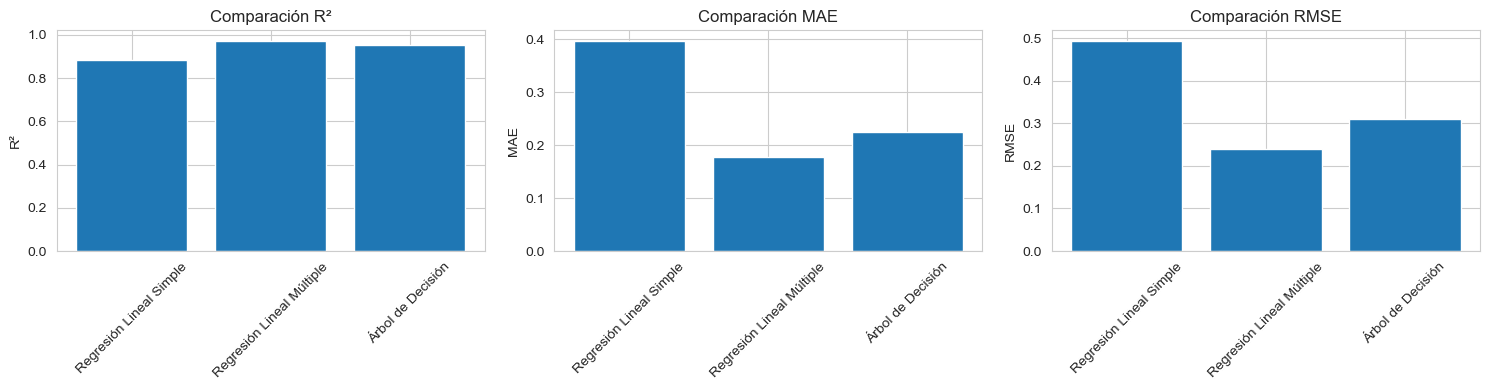


🏆 El mejor modelo es: Regresión Lineal Múltiple con R² = 0.9722


In [52]:
# Comparativa final de todos los modelos
comparativa = pd.DataFrame({
    'Modelo': ['Regresión Lineal Simple', 'Regresión Lineal Múltiple', 'Árbol de Decisión'],
    'R²': [r2_simple, r2_multiple, r2_tree],
    'MAE': [mae_simple, mae_multiple, mae_tree],
    'RMSE': [rmse_simple, rmse_multiple, rmse_tree]
})

print("\n" + "="*60)
print("COMPARATIVA DE MODELOS")
print("="*60)
print(comparativa.to_string(index=False))
print("="*60)

# Visualizar comparativa
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metricas = ['R²', 'MAE', 'RMSE']
for i, metrica in enumerate(metricas):
    axes[i].bar(comparativa['Modelo'], comparativa[metrica])
    axes[i].set_ylabel(metrica)
    axes[i].set_title(f'Comparación {metrica}')
    axes[i].tick_params(axis='x', rotation=45)
    
plt.tight_layout()
plt.show()

# Identificar mejor modelo
mejor_modelo_idx = comparativa['R²'].idxmax()
mejor_modelo = comparativa.loc[mejor_modelo_idx, 'Modelo']
print(f"\n🏆 El mejor modelo es: {mejor_modelo} con R² = {comparativa.loc[mejor_modelo_idx, 'R²']:.4f}")

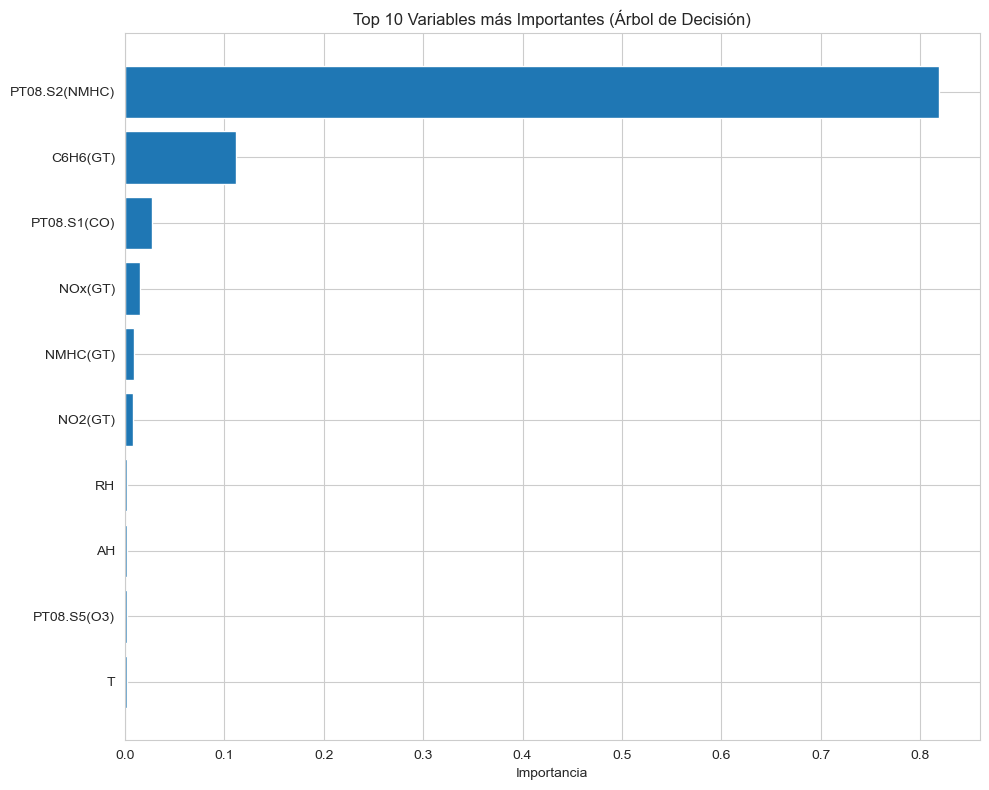


Top 5 variables más importantes según el árbol de decisión:
        Variable  Importancia
3  PT08.S2(NMHC)     0.819185
2       C6H6(GT)     0.111858
0    PT08.S1(CO)     0.027500
4        NOx(GT)     0.014912
1       NMHC(GT)     0.009023


In [49]:
# Visualización de importancia de características en árbol de decisión
importancias = pd.DataFrame({
    'Variable': X_train_scaled.columns,
    'Importancia': modelo_tree.feature_importances_
}).sort_values('Importancia', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(importancias['Variable'].head(10), importancias['Importancia'].head(10))
plt.xlabel('Importancia')
plt.title('Top 10 Variables más Importantes (Árbol de Decisión)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 5 variables más importantes según el árbol de decisión:")
print(importancias.head())

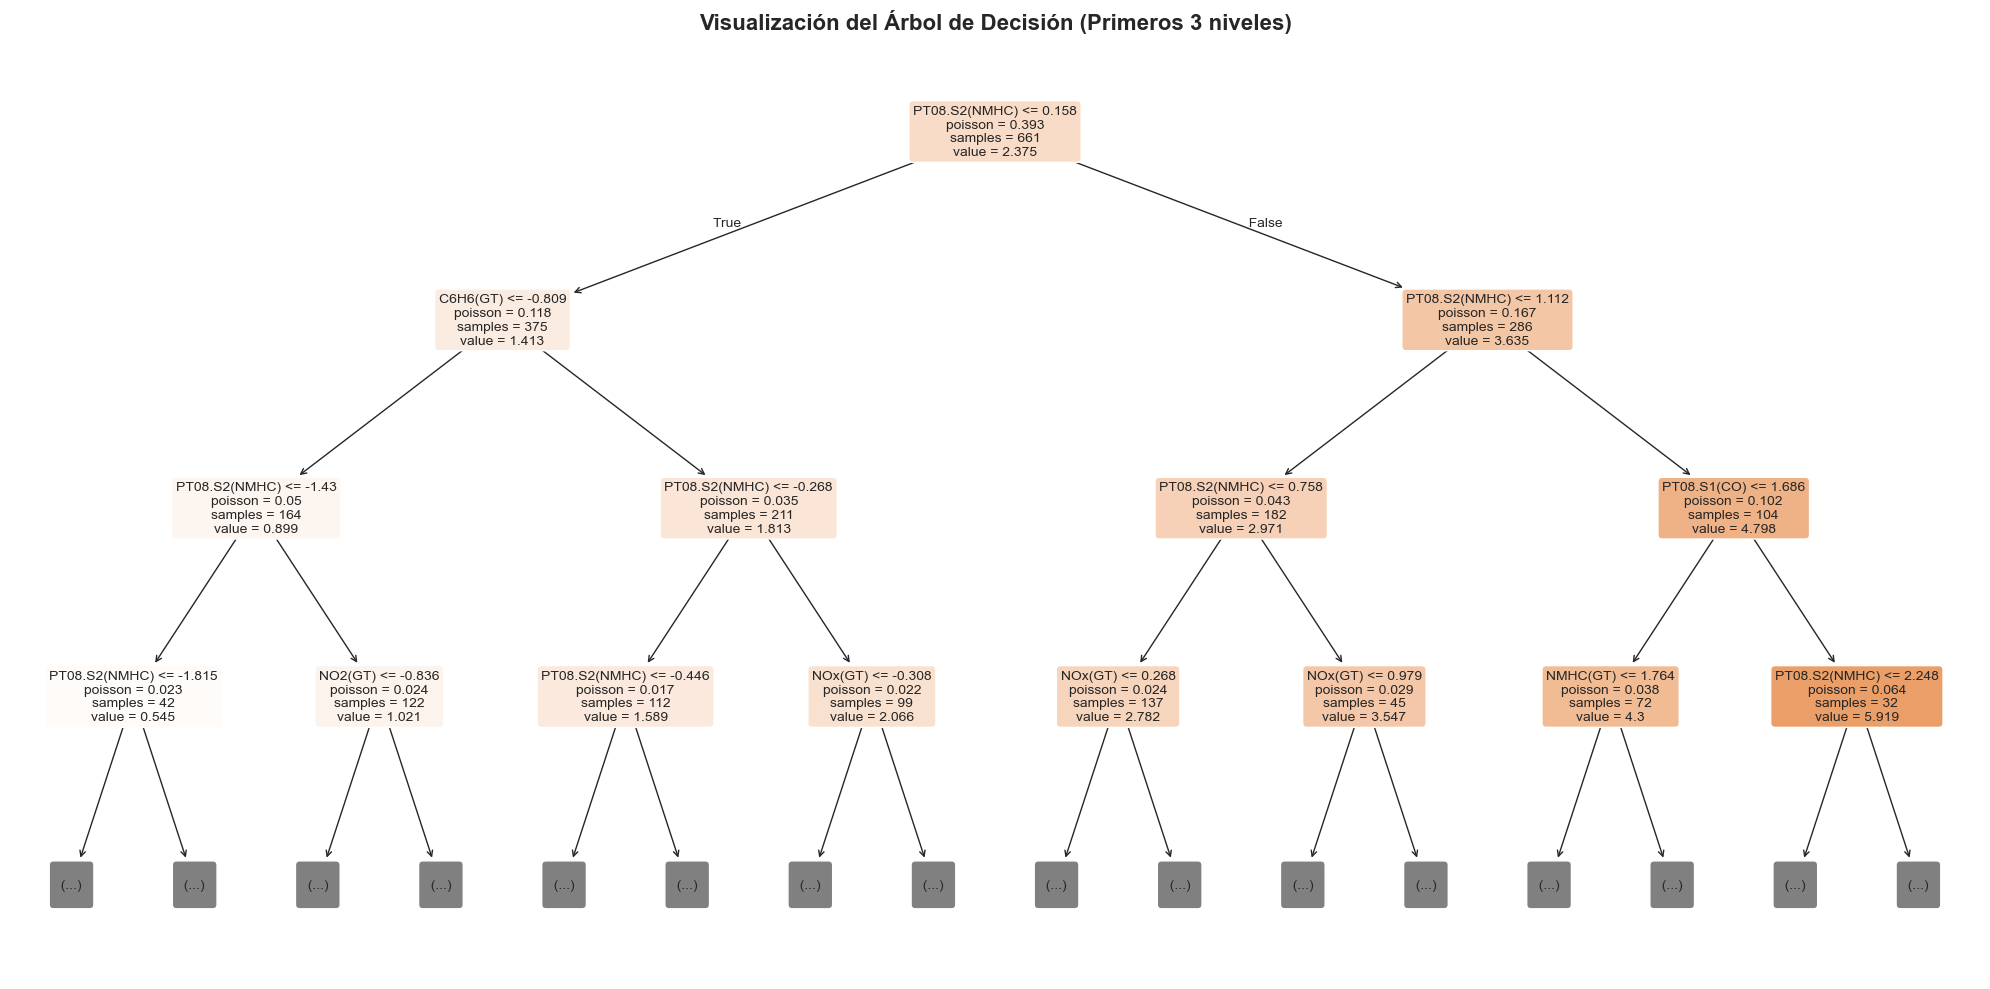


REGLAS DEL ÁRBOL DE DECISIÓN (Primeros 3 niveles)
|--- PT08.S2(NMHC) <= 0.16
|   |--- C6H6(GT) <= -0.81
|   |   |--- PT08.S2(NMHC) <= -1.43
|   |   |   |--- PT08.S2(NMHC) <= -1.82
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- PT08.S2(NMHC) >  -1.82
|   |   |   |   |--- truncated branch of depth 4
|   |   |--- PT08.S2(NMHC) >  -1.43
|   |   |   |--- NO2(GT) <= -0.84
|   |   |   |   |--- truncated branch of depth 7
|   |   |   |--- NO2(GT) >  -0.84
|   |   |   |   |--- truncated branch of depth 6
|   |--- C6H6(GT) >  -0.81
|   |   |--- PT08.S2(NMHC) <= -0.27
|   |   |   |--- PT08.S2(NMHC) <= -0.45
|   |   |   |   |--- truncated branch of depth 6
|   |   |   |--- PT08.S2(NMHC) >  -0.45
|   |   |   |   |--- truncated branch of depth 6
|   |   |--- PT08.S2(NMHC) >  -0.27
|   |   |   |--- NOx(GT) <= -0.31
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- NOx(GT) >  -0.31
|   |   |   |   |--- truncated branch of depth 7
|--- PT08.S2(NMHC) >  0.16
|   |--- 

In [50]:
# Visualizar el árbol de decisión
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(modelo_tree, 
          feature_names=X_train_scaled.columns,
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=3)  # Limitamos a 3 niveles para que sea legible
plt.title('Visualización del Árbol de Decisión (Primeros 3 niveles)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Alternativa: Representación textual del árbol (primeros niveles)
from sklearn.tree import export_text
tree_rules = export_text(modelo_tree, 
                         feature_names=list(X_train_scaled.columns),
                         max_depth=3)
print("\n" + "="*80)
print("REGLAS DEL ÁRBOL DE DECISIÓN (Primeros 3 niveles)")
print("="*80)
print(tree_rules)

## Investigación

**Referencia:**  
Patel, J., Shah, S., Thakkar, P., & Kotecha, K. (2015). *Predicting stock market index using fusion of machine learning techniques*. **International Journal of Recent Technology and Engineering (IJRTE)**, 4(1), 57–62.

**Objetivo:**  
El objetivo principal del artículo es analizar la viabilidad de técnicas clásicas de regresión y aprendizaje automático para la predicción de índices bursátiles. En particular, el estudio busca estimar la evolución futura del mercado financiero a partir de datos históricos, como los precios de apertura y cierre, valores máximos y mínimos diarios, y el volumen de negociación. La motivación del trabajo radica en proporcionar modelos predictivos que sirvan de apoyo a la toma de decisiones financieras, reduciendo la incertidumbre asociada a la inversión en mercados altamente dinámicos.

**Técnicas empleadas:**  
El estudio utiliza **regresión lineal** como técnica de referencia debido a su simplicidad, interpretabilidad y bajo coste computacional. Este modelo se emplea para establecer relaciones lineales entre las variables predictoras del mercado y el valor del índice bursátil. Adicionalmente, se comparan sus resultados con otros métodos clásicos de aprendizaje automático, como Support Vector Machines y Random Forest, con el fin de evaluar las limitaciones de la regresión frente a modelos capaces de capturar relaciones no lineales. En ningún caso se aplican técnicas de Deep Learning, manteniendo el enfoque en modelos tradicionales.

**Principales resultados:**  
Los resultados experimentales muestran que la regresión lineal es capaz de modelar adecuadamente las tendencias generales del mercado bursátil, ofreciendo un rendimiento aceptable en escenarios de comportamiento estable. No obstante, el estudio evidencia que su capacidad predictiva disminuye en contextos de alta volatilidad, donde las relaciones entre variables no son estrictamente lineales. En comparación con otros algoritmos clásicos, la regresión lineal presenta una mayor interpretabilidad y estabilidad, aunque a costa de una menor precisión. El artículo concluye que la regresión lineal es una herramienta útil como modelo base y de análisis exploratorio, pero recomienda el uso de técnicas más avanzadas cuando se requiere una mayor capacidad predictiva.


# Uso de Inteligencia Artificial en la elaboración del proyecto

Durante la elaboración de este proyecto se ha utilizado inteligencia artificial como herramienta de apoyo para la redacción del documento, la estructuración de contenidos, la generación y optimización de código en Python y la realización del análisis exploratorio de los datos. La IA ha servido para proponer implementaciones iniciales, mejorar la claridad del código y facilitar la elaboración de visualizaciones, pero **todas las decisiones metodológicas, la interpretación de los resultados y las conclusiones finales han sido tomadas de manera autónoma por el autor**. Todo el contenido generado ha sido revisado, validado y, en su caso, modificado para garantizar su corrección técnica, la coherencia con los objetivos del proyecto y el cumplimiento de los estándares académicos, manteniendo en todo momento la responsabilidad y el pensamiento crítico del autor.
